# Multi-panel colouring in spatialdata-plot

Passing a **list** to `color=` renders one panel per colouring in a single figure, the same way `scanpy`'s `color=[...]` works. By the end you should be able to:

- Turn a single `render_labels`/`render_shapes` call into a grid of panels.
- Mix categorical and continuous colourings in one figure, each with its own legend or colourbar.
- Control the grid width with `show(ncols=...)` and share `palette`/`cmap` across panels.

We use the synthetic `blobs` dataset throughout so the notebook stays small and reproducible.

## Setup

In [1]:
import numpy as np
import pandas as pd

import spatialdata as sd
import spatialdata_plot  # noqa: F401  # registers the .pl accessor

sdata = sd.datasets.blobs()

rng = np.random.default_rng(0)

# A categorical and (built-in) continuous columns on the table annotate blobs_labels.
table = sdata.tables['table']
table.obs['cell_type'] = pd.Categorical(
    rng.choice(['A', 'B', 'C', 'D', 'E'], size=table.n_obs),
    categories=['A', 'B', 'C', 'D', 'E'],
)

# A categorical and a continuous column directly on a shapes GeoDataFrame.
sdata.shapes['blobs_polygons']['region_type'] = pd.Categorical(
    ['stroma', 'tumour', 'stroma', 'immune', 'tumour'],
)
sdata.shapes['blobs_polygons']['score'] = rng.random(len(sdata.shapes['blobs_polygons']))
sdata

SpatialData object
├── Images
│     ├── 'blobs_image': DataArray[cyx] (3, 512, 512)
│     └── 'blobs_multiscale_image': DataTree[cyx] (3, 512, 512), (3, 256, 256), (3, 128, 128)
├── Labels
│     ├── 'blobs_labels': DataArray[yx] (512, 512)
│     └── 'blobs_multiscale_labels': DataTree[yx] (512, 512), (256, 256), (128, 128)
├── Points
│     └── 'blobs_points': DataFrame with shape: (<Delayed>, 4) (2D points)
├── Shapes
│     ├── 'blobs_circles': GeoDataFrame shape: (5, 2) (2D shapes)
│     ├── 'blobs_multipolygons': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'blobs_polygons': GeoDataFrame shape: (5, 3) (2D shapes)
└── Tables
      └── 'table': AnnData (26, 3)
with coordinate systems:
    ▸ 'global', with elements:
        blobs_image (Images), blobs_multiscale_image (Images), blobs_labels (Labels), blobs_multiscale_labels (Labels), blobs_points (Points), blobs_circles (Shapes), blobs_multipolygons (Shapes), blobs_polygons (Shapes)

## 1. From one colouring to many

A single string colours one panel. Pass a **list** and each entry becomes its own panel of the same element — one figure, many colourings. `show(ncols=...)` lays the panels out in a grid.

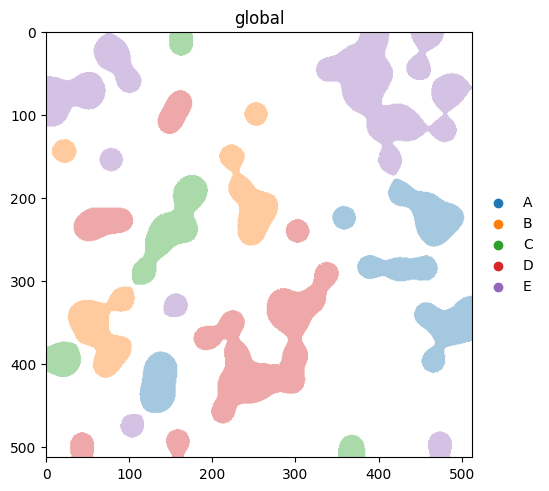

In [2]:
sdata.pl.render_labels('blobs_labels', color='cell_type').pl.show()

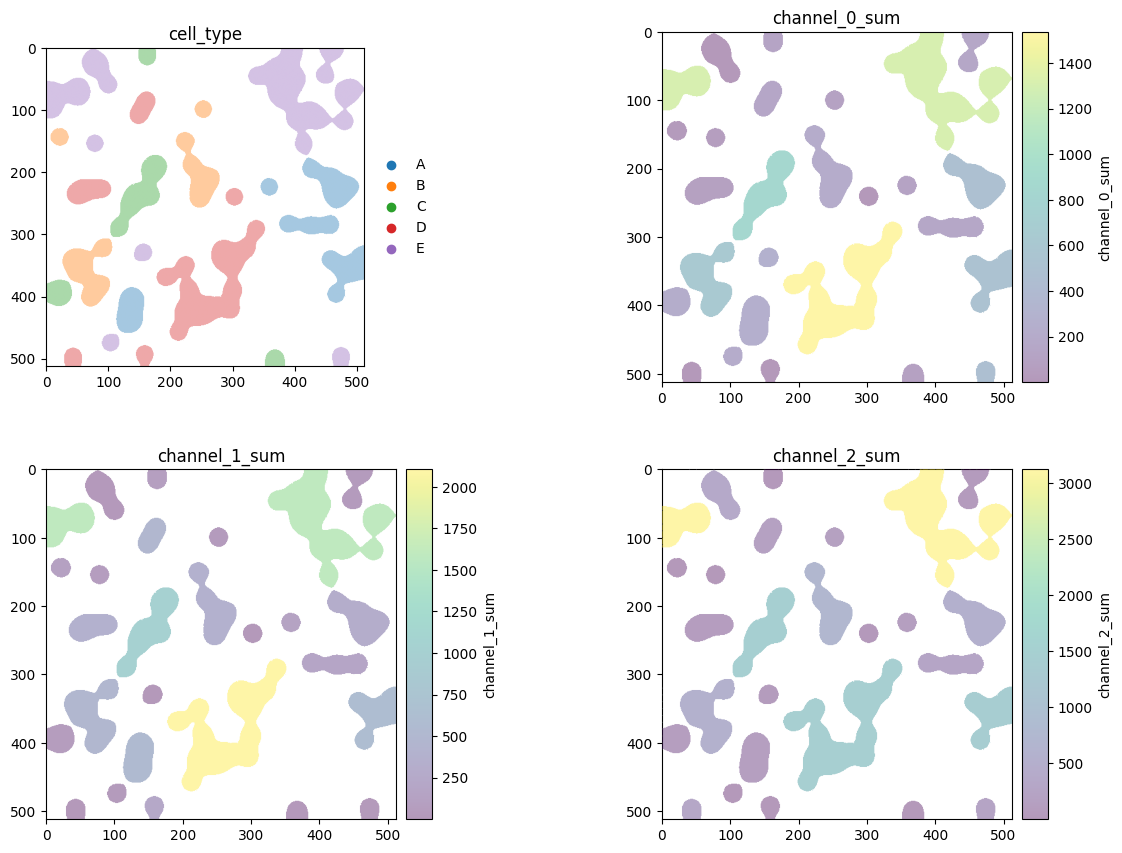

In [3]:
# Four colourings of the same labels, arranged 2x2.
sdata.pl.render_labels(
    'blobs_labels',
    color=['cell_type', 'channel_0_sum', 'channel_1_sum', 'channel_2_sum'],
).pl.show(ncols=2)

## 2. Mixing categorical and continuous

The panels above already mix a categorical colouring (`cell_type`, drawn with a legend) with continuous ones (the channel sums, drawn with colourbars). Each panel **auto-scales independently**, so a channel with a small dynamic range still uses the full colourmap rather than being flattened against a brighter channel.

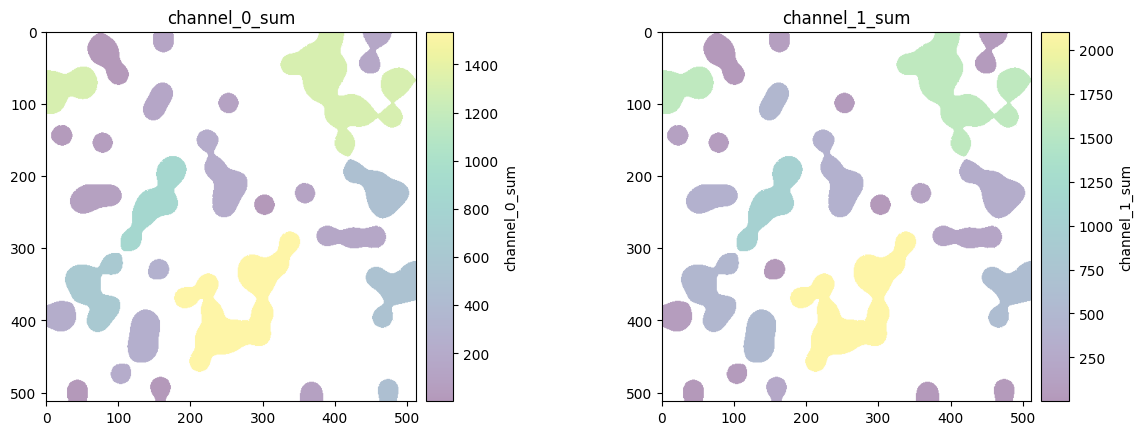

In [4]:
sdata.pl.render_labels(
    'blobs_labels',
    color=['channel_0_sum', 'channel_1_sum'],
).pl.show()

## 3. Multi-panel `render_shapes`

The list form works identically for shapes. Here a categorical (`region_type`) and a continuous column (`score`) on the same polygons render side by side.

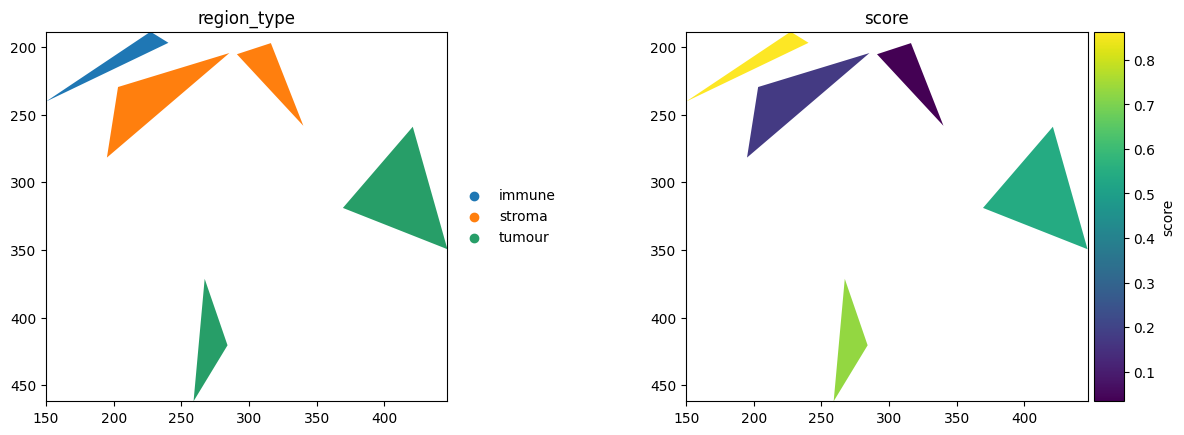

In [5]:
sdata.pl.render_shapes(
    'blobs_polygons',
    color=['region_type', 'score'],
).pl.show()

## 4. Controlling the grid with `ncols`

`ncols` sets how many panels sit in a row; the rest wrap onto new rows. The same four colourings become a single row with `ncols=4` or a 2x2 grid with `ncols=2`.

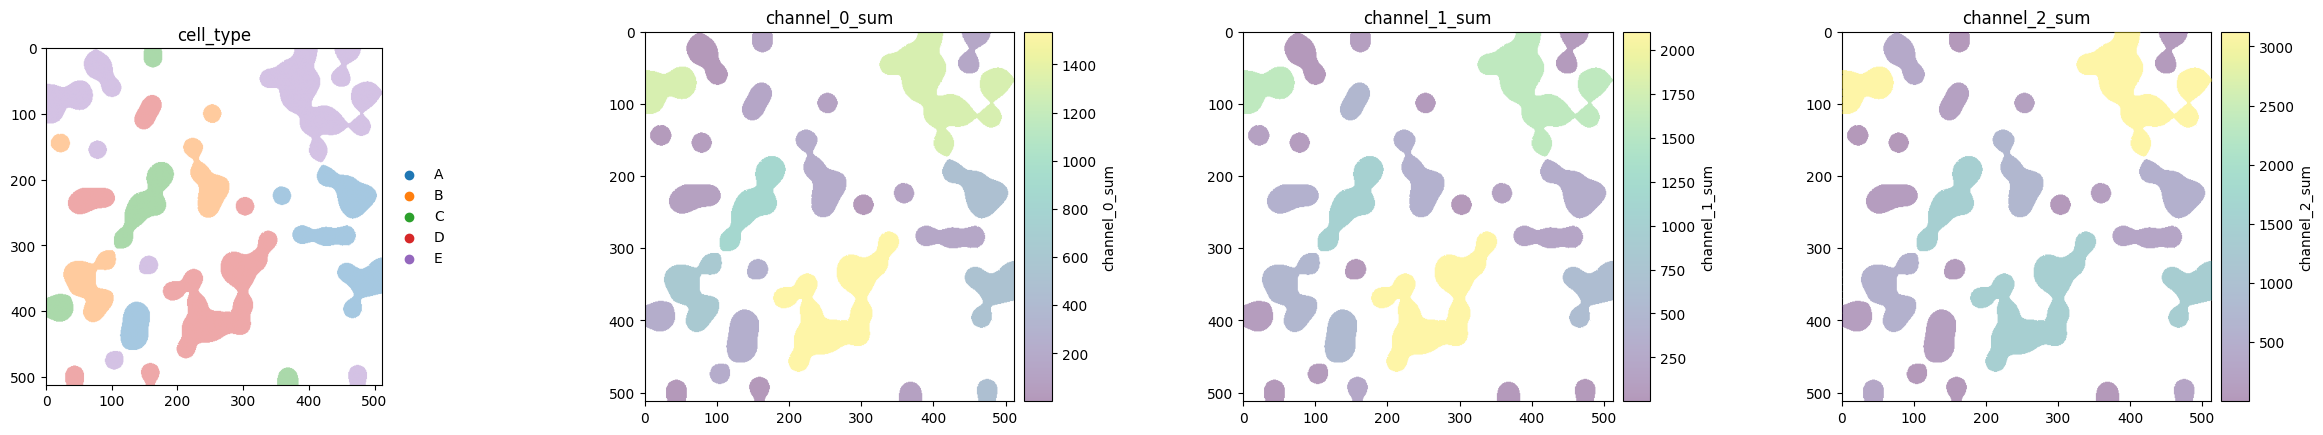

In [6]:
sdata.pl.render_labels(
    'blobs_labels',
    color=['cell_type', 'channel_0_sum', 'channel_1_sum', 'channel_2_sum'],
).pl.show(ncols=4)

## 5. Shared `palette` / `cmap` / `norm` across panels

`palette`, `cmap`, `norm` and `groups` are applied to **every** panel, so a single keyword styles the whole figure. Autoscaling still happens per panel unless you pin it with an explicit `norm`.

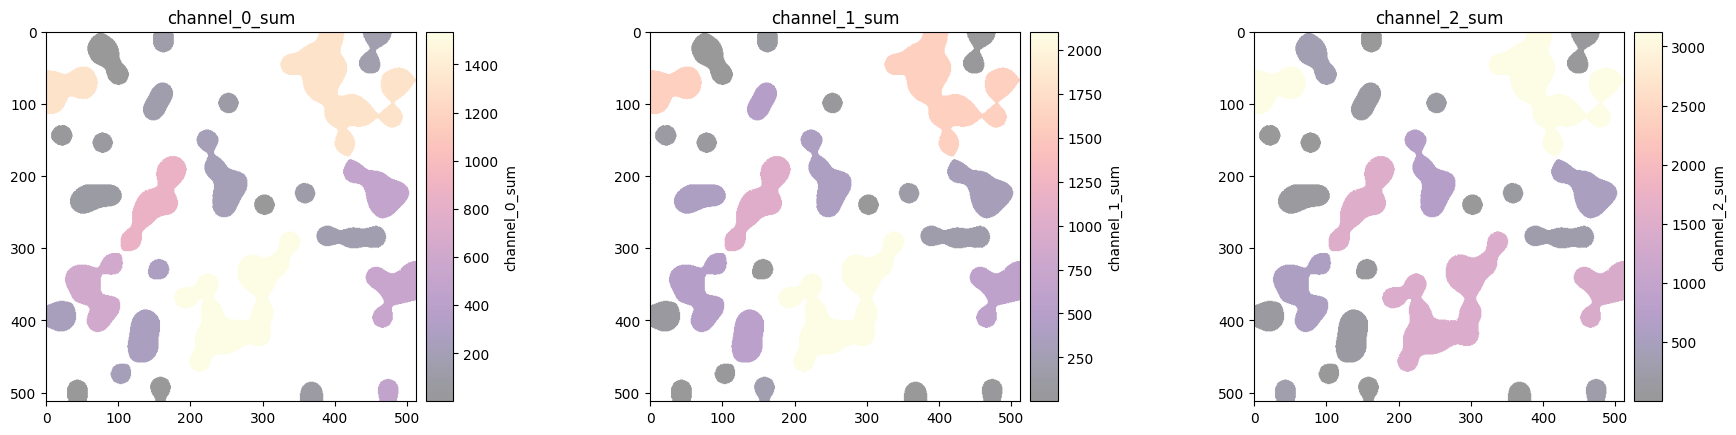

In [7]:
sdata.pl.render_labels(
    'blobs_labels',
    color=['channel_0_sum', 'channel_1_sum', 'channel_2_sum'],
    cmap='magma',
).pl.show(ncols=3)

## For reproducibility

In [8]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import dask
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,matplotlib,numpy,pandas

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
matplotlib      : 3.10.9
numpy           : 2.4.4
pandas          : 2.3.3

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

